# 04 - ResNet-50 for NIH Chest X-Ray Classification

Multi-label classification of 14 diseases using ResNet-50 with:
- CLAHE preprocessing + Adaptive Lung Crop
- Focal Loss with Label Smoothing
- GroupKFold cross-validation by Patient ID
- Per-class optimal threshold tuning

## 1. Setup & Imports

In [1]:
import os
from glob import glob
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import GroupKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms as T, models

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# CUDA optimizations
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Configuration

In [2]:
# ==================== PATHS ====================
ROOT = Path('/kaggle/input/datasets/organizations/nih-chest-xrays/data')
CSV_PATH = ROOT / 'Data_Entry_2017.csv'
TRAIN_SPLIT = Path('/kaggle/input/datasets/zoey041/nih-subset/train_subset.txt')
TEST_SPLIT = Path('/kaggle/input/datasets/zoey041/nih-subset/test_subset.txt')

OUT_DIR = Path('/kaggle/working/output')
ENS_DIR = OUT_DIR / 'ensemble_inputs'
ENS_DIR.mkdir(parents=True, exist_ok=True)

# Get all image paths
all_image_paths = {
    os.path.basename(p): p 
    for p in glob(f'{ROOT}/images_*/images/*.png')
}
print(f'Total images found: {len(all_image_paths)}')

# ==================== DISEASE LABELS ====================
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# ==================== MODEL CONFIG ====================
MODEL_KEY = 'resnet'
MODEL_NAME = 'resnet50'
IMAGE_SIZE = 256
DROPOUT_RATE = 0.3

# ==================== TRAINING CONFIG ====================
BATCH_SIZE = 32
NUM_WORKERS = 4
LR = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

# Focal Loss parameters
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 1.0

# Training modes
EARLY_EPOCHS = 15
EARLY_PATIENCE = 5
FULL_EPOCHS = 20

print('\n=== Training Configuration ===')
print(f'Model: {MODEL_NAME}')
print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Learning rate: {LR}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Label smoothing: {LABEL_SMOOTHING}')
print(f'Focal Loss: alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}')

Total images found: 112120

=== Training Configuration ===
Model: resnet50
Image size: 256x256
Batch size: 32
Learning rate: 0.0005
Weight decay: 0.0001
Label smoothing: 0.1
Focal Loss: alpha=1.0, gamma=2.0


## 3. Load Data

In [3]:
# Load labels
labels = pd.read_csv(CSV_PATH)
labels = labels.rename(columns={
    'Image Index': 'Image_index', 
    'Finding Labels': 'Finding_labels', 
    'Patient ID': 'Patient_id'
})

# Create binary labels for each disease
label_cols = labels['Finding_labels'].str.get_dummies(sep='|')[DISEASES]
labels = pd.concat([labels[['Image_index', 'Patient_id']], label_cols], axis=1)

# Load train/test splits
with open(TRAIN_SPLIT, 'r') as f:
    train_list = f.read().split('\n')
with open(TEST_SPLIT, 'r') as f:
    test_list = f.read().split('\n')

train_labels = labels[labels['Image_index'].isin(train_list)].copy()
test_labels = labels[labels['Image_index'].isin(test_list)].copy()

print('=== Dataset Information ===')
print(f'Train: {len(train_labels)} images, {train_labels["Patient_id"].nunique()} patients')
print(f'Test: {len(test_labels)} images, {test_labels["Patient_id"].nunique()} patients')

=== Dataset Information ===
Train: 15155 images, 5000 patients
Test: 4788 images, 500 patients


## 4. Preprocessing

In [4]:
class AdaptiveLungCropCLAHE:
    """
    Adaptive preprocessing for chest X-rays:
    1. Convert to grayscale
    2. Apply Otsu's thresholding to find lung region
    3. Crop to lung bounding box with padding
    4. Apply CLAHE for contrast enhancement
    5. Resize to target size
    """
    def __init__(self, out_size, clip_limit=2.0, pad=12):
        self.out_size = out_size
        self.clip_limit = clip_limit
        self.pad = pad

    def __call__(self, img):
        arr = np.array(img.convert('L'))
        blur = cv2.GaussianBlur(arr, (5, 5), 0)
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        ys, xs = np.where(mask > 0)
        if len(xs) > 0 and len(ys) > 0:
            x1 = max(xs.min() - self.pad, 0)
            x2 = min(xs.max() + self.pad, arr.shape[1] - 1)
            y1 = max(ys.min() - self.pad, 0)
            y2 = min(ys.max() + self.pad, arr.shape[0] - 1)
            arr = arr[y1:y2+1, x1:x2+1]
        
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=(8, 8))
        arr = clahe.apply(arr)
        arr = cv2.resize(arr, (self.out_size, self.out_size), interpolation=cv2.INTER_AREA)
        return Image.fromarray(cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB))

In [5]:
class XrayDataset(Dataset):
    """Dataset class for chest X-ray images."""
    
    def __init__(self, data, image_paths, transform):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = row['Image_index']
        img_path = self.image_paths[img_name]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        label = row[DISEASES].values.astype(np.float32)
        return img, label

In [6]:
def build_transforms():
    """Build train and validation transforms."""
    adaptive = AdaptiveLungCropCLAHE(IMAGE_SIZE)
    
    train_transform = T.Compose([
        adaptive,
        T.RandomRotation(15),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ColorJitter(brightness=0.15, contrast=0.15),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    valid_transform = T.Compose([
        adaptive,
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    return train_transform, valid_transform

## 5. Model Architecture

In [7]:
class ImprovedResNet(nn.Module):
    """
    ResNet-50 with custom classifier head.
    
    Architecture:
    - Pretrained ResNet-50 backbone (layer1-2 frozen)
    - Custom classifier: Linear(2048->512) -> BN -> ReLU -> Dropout
                       -> Linear(512->256) -> BN -> ReLU -> Dropout
                       -> Linear(256->14)
    """
    
    def __init__(self, num_classes=14, dropout_rate=0.3):
        super().__init__()
        
        # Load pretrained backbone
        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )
        
        # Freeze early layers (layer1 and layer2)
        for name, param in self.backbone.named_parameters():
            if any(f'layer{i}' in name for i in [1, 2]):
                param.requires_grad = False
        
        # Get number of features from original fc layer
        num_features = self.backbone.fc.in_features  # 2048
        
        # Replace fc with custom head
        self.backbone.fc = nn.Sequential(
            # First block: 2048 -> 512
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            
            # Second block: 512 -> 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            
            # Output layer
            nn.Linear(256, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize classifier weights using Kaiming initialization."""
        for m in self.backbone.fc.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.backbone(x)


# Test model
model = ImprovedResNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model: {MODEL_NAME}')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Frozen parameters: {total_params - trainable_params:,}')
del model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


Model: resnet50
Total parameters: 24,693,582
Trainable parameters: 23,258,190
Frozen parameters: 1,435,392


## 6. Loss Function

In [8]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.label_smoothing = label_smoothing
    
    def forward(self, inputs, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2
        
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets, 
            pos_weight=self.pos_weight, 
            reduction='none'
        )
        pt = torch.exp(-bce)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce
        return focal_loss.mean()


def compute_pos_weights(df, disease_cols):
    pos_counts = df[disease_cols].sum().values
    neg_counts = len(df) - pos_counts
    pos_weights = neg_counts / (pos_counts + 1e-6)
    return torch.tensor(np.clip(pos_weights, 1.0, 50.0), dtype=torch.float32)


pos_weights = compute_pos_weights(train_labels, DISEASES).to(DEVICE)
print('\n=== Positive Class Weights ===')
for disease, weight in zip(DISEASES, pos_weights.cpu().numpy()):
    print(f'{disease:20s}: {weight:.1f}')


=== Positive Class Weights ===
Atelectasis         : 9.6
Cardiomegaly        : 49.7
Consolidation       : 27.6
Edema               : 50.0
Effusion            : 8.8
Emphysema           : 50.0
Fibrosis            : 50.0
Hernia              : 50.0
Infiltration        : 5.2
Mass                : 20.1
Nodule              : 17.5
Pleural_Thickening  : 36.7
Pneumonia           : 50.0
Pneumothorax        : 29.2


## 7. Training Functions

In [9]:
def macro_auc(y_true, y_prob):
    try:
        return float(roc_auc_score(y_true, y_prob, average='macro'))
    except:
        return 0.0


def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            
            with autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    y_true = np.vstack(all_labels)
    y_prob = np.vstack(all_preds)
    avg_loss = total_loss / len(loader)
    auc = macro_auc(y_true, y_prob)
    
    return avg_loss, auc, y_true, y_prob

In [10]:
PIN_MEMORY = torch.cuda.is_available()

def run_single_fold(df_train, df_val, fold_idx, mode_name, max_epochs, patience):
    print(f'\n{"="*50}')
    print(f'Fold {fold_idx} | Mode: {mode_name} | Epochs: {max_epochs}')
    print(f'{"="*50}')
    
    train_tf, valid_tf = build_transforms()
    train_ds = XrayDataset(df_train, all_image_paths, train_tf)
    val_ds = XrayDataset(df_val, all_image_paths, valid_tf)
    
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    
    print(f'Train size: {len(train_ds)}, Val size: {len(val_ds)}')
    
    model = ImprovedResNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE).to(DEVICE)
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    
    iters_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=iters_per_epoch * 2, T_mult=2, eta_min=1e-6
    )
    scaler = GradScaler('cuda') if torch.cuda.is_available() else None
    
    best_auc = -1.0
    best_state = None
    best_val_pred = None
    wait = 0
    
    ckpt_dir = OUT_DIR / MODEL_KEY / mode_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f'fold_{fold_idx}_checkpoint.pt'
    start_epoch = 0
    
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_auc = ckpt['val_auc']
        wait = ckpt.get('wait', 0)
        print(f'Resumed from epoch {start_epoch}, AUC={best_auc:.4f}')
    
    for epoch in range(start_epoch, max_epochs):
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{max_epochs} [Train]', leave=False)
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            
            optimizer.zero_grad(set_to_none=True)
            
            with autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step(epoch + batch_idx / iters_per_epoch)
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = train_loss / len(train_loader)
        val_loss, val_auc, y_true_val, y_prob_val = evaluate_epoch(model, val_loader, criterion)
        val_acc = ((y_prob_val >= 0.5) == y_true_val).mean() * 100
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f'Epoch {epoch+1}/{max_epochs}: '
              f'Train Loss = {avg_train_loss:.4f} | '
              f'Val Loss = {val_loss:.4f} | '
              f'Val Acc = {val_acc:.2f}% | '
              f'Val AUC = {val_auc*100:.2f}% | '
              f'LR = {current_lr:.2e}')
        
        if val_auc > best_auc:
            print(f'=> Val AUC improved ({best_auc*100:.2f}% -> {val_auc*100:.2f}%). Saving model...')
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_val_pred = y_prob_val
            wait = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_auc,
                'wait': wait
            }, ckpt_path)
        else:
            wait += 1
        
        if mode_name == 'early_stop' and wait >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    if best_state:
        model.load_state_dict(best_state)
    
    if best_val_pred is None:
        _, best_auc, y_true_val, best_val_pred = evaluate_epoch(model, val_loader, criterion)
    
    return model, best_auc, y_true_val, best_val_pred

## 8. Run Training

In [11]:
RUN_MODES = [
    {'name': 'early_stop', 'epochs': EARLY_EPOCHS, 'patience': EARLY_PATIENCE},
    {'name': 'full_epoch', 'epochs': FULL_EPOCHS, 'patience': FULL_EPOCHS},
]

gkf = GroupKFold(n_splits=3)
groups = train_labels['Patient_id'].values

best_mode_name = None
best_mode_auc = -1.0
best_mode_artifacts = None

for mode in RUN_MODES:
    mode_name = mode['name']
    print(f'\n{"="*60}')
    print(f'MODE: {mode_name.upper()} | Epochs: {mode["epochs"]}')
    print(f'{"="*60}')
    
    fold_oof = np.zeros((len(train_labels), len(DISEASES)), dtype=np.float32)
    fold_test_probs = []
    fold_aucs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups), 1):
        print(f'\n--- Fold {fold_idx}/3 ---')
        
        df_train = train_labels.iloc[train_idx].copy()
        df_val = train_labels.iloc[val_idx].copy()
        
        model, fold_auc, _, y_prob_val = run_single_fold(
            df_train, df_val, fold_idx, mode_name, 
            mode['epochs'], mode['patience']
        )
        
        fold_aucs.append(fold_auc)
        fold_oof[val_idx] = y_prob_val.astype(np.float32)
        
        _, valid_tf = build_transforms()
        test_ds = XrayDataset(test_labels, all_image_paths, valid_tf)
        test_loader = DataLoader(
            test_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        )
        
        model.eval()
        test_preds = []
        with torch.no_grad():
            for images, _ in test_loader:
                with autocast('cuda', enabled=torch.cuda.is_available()):
                    preds = torch.sigmoid(model(images.to(DEVICE)))
                test_preds.append(preds.cpu().numpy())
        fold_test_probs.append(np.vstack(test_preds))
        
        save_path = OUT_DIR / MODEL_KEY / mode_name / f'fold_{fold_idx}.pt'
        torch.save(model.state_dict(), save_path)
        print(f'Fold {fold_idx} complete | AUC = {fold_auc*100:.2f}%')
    
    mode_auc = macro_auc(train_labels[DISEASES].values, fold_oof)
    print(f'\n[{mode_name}] OOF AUC = {mode_auc*100:.2f}%')
    print(f'Fold AUCs: {[f"{a*100:.2f}%" for a in fold_aucs]}')
    
    if mode_auc > best_mode_auc:
        best_mode_auc = mode_auc
        best_mode_name = mode_name
        best_mode_artifacts = {
            'oof': fold_oof,
            'test_probs': np.mean(np.stack(fold_test_probs), axis=0),
            'fold_aucs': fold_aucs
        }

print(f'\n{"="*60}')
print(f'BEST MODE: {best_mode_name} | OOF AUC = {best_mode_auc*100:.2f}%')
print(f'{"="*60}')


MODE: EARLY_STOP | Epochs: 15

--- Fold 1/3 ---

Fold 1 | Mode: early_stop | Epochs: 15
Train size: 10103, Val size: 5052


Epoch 1/15 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 1/15: Train Loss = 0.2629 | Val Loss = 0.0605 | Val Acc = 95.37% | Val AUC = 54.42% | LR = 5.00e-04
=> Val AUC improved (-100.00% -> 54.42%). Saving model...


Epoch 2/15 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 2/15: Train Loss = 0.1005 | Val Loss = 0.1089 | Val Acc = 95.37% | Val AUC = 61.29% | LR = 5.00e-04
=> Val AUC improved (54.42% -> 61.29%). Saving model...


...

Epoch 18/20: Train Loss = 0.0622 | Val Loss = 0.0951 | Val Acc = 95.55% | Val AUC = 67.94% | LR = 4.99e-04


Epoch 19/20 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 19/20: Train Loss = 0.0627 | Val Loss = 0.7450 | Val Acc = 95.55% | Val AUC = 69.12% | LR = 4.99e-04


Epoch 20/20 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 20/20: Train Loss = 0.0639 | Val Loss = 0.2689 | Val Acc = 95.55% | Val AUC = 68.99% | LR = 4.99e-04
Fold 3 complete | AUC = 69.54%

[full_epoch] OOF AUC = 68.45%
Fold AUCs: ['69.96%', '68.28%', '69.54%']

BEST MODE: early_stop | OOF AUC = 69.18%


## 9. Out-of-Fold Results

In [12]:
y_true = train_labels[DISEASES].values.astype(np.int32)
y_prob = best_mode_artifacts['oof']
y_pred = (y_prob >= 0.5).astype(np.int32)

results = []
for i, disease in enumerate(DISEASES):
    yt = y_true[:, i]
    yp = y_prob[:, i]
    yb = y_pred[:, i]
    
    try:
        auc = roc_auc_score(yt, yp)
    except:
        auc = 0.0
    
    results.append({
        'Disease': disease,
        'AUC': round(auc * 100, 2),
        'F1': round(f1_score(yt, yb, zero_division=0) * 100, 2),
        'Precision': round(precision_score(yt, yb, zero_division=0) * 100, 2),
        'Recall': round(recall_score(yt, yb, zero_division=0) * 100, 2)
    })

report_df = pd.DataFrame(results).sort_values('AUC', ascending=False)

print('\n=== Out-of-Fold Performance (Best Mode) ===')
print(report_df.to_string(index=False))
print(f'\nMacro AUC: {report_df["AUC"].mean():.2f}%')
print(f'Macro F1: {report_df["F1"].mean():.2f}%')


=== Out-of-Fold Performance (Best Mode) ===
           Disease   AUC    F1  Precision  Recall
             Edema 84.46  0.00       0.00    0.00
          Effusion 84.31 24.43      59.25   15.39
     Consolidation 76.76  0.00       0.00    0.00
         Emphysema 72.94  0.00       0.00    0.00
      Pneumothorax 72.84  0.00       0.00    0.00
       Atelectasis 72.38  0.00       0.00    0.00
Pleural_Thickening 69.08  0.00       0.00    0.00
         Pneumonia 66.96  0.00       0.00    0.00
              Mass 66.84  0.00       0.00    0.00
          Fibrosis 64.73  0.00       0.00    0.00
      Infiltration 62.91  0.00       0.00    0.00
      Cardiomegaly 60.22  0.00       0.00    0.00
            Nodule 58.63  0.00       0.00    0.00
            Hernia 55.47  0.00       0.00    0.00

Macro AUC: 69.18%
Macro F1: 1.74%


In [13]:
# Save predictions
oof_df = pd.DataFrame({
    'Image_index': train_labels['Image_index'],
    **{d: y_prob[:, i] for i, d in enumerate(DISEASES)}
})
oof_df.to_csv(ENS_DIR / f'{MODEL_KEY}_oof_probs.csv', index=False)

test_probs = best_mode_artifacts['test_probs']
test_df = pd.DataFrame({
    'Image_index': test_labels['Image_index'],
    **{d: test_probs[:, i] for i, d in enumerate(DISEASES)}
})
test_df.to_csv(ENS_DIR / f'{MODEL_KEY}_test_probs.csv', index=False)

summary = {
    'model_key': MODEL_KEY,
    'best_mode': best_mode_name,
    'oof_auc': float(best_mode_auc),
    'fold_aucs': [float(x) for x in best_mode_artifacts['fold_aucs']]
}
with open(ENS_DIR / f'{MODEL_KEY}_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

report_df.to_csv(ENS_DIR / f'{MODEL_KEY}_metrics.csv', index=False)
print(f'Saved predictions to {ENS_DIR}')

Saved predictions to /kaggle/working/output/ensemble_inputs


## 10. Optimal Threshold Tuning

In [14]:
def find_optimal_thresholds(y_true, y_prob, disease_cols, min_precision=0.15):
    optimal_thresholds = {}
    results = []
    
    for i, col in enumerate(disease_cols):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        
        best_f1 = 0
        best_threshold = 0.5
        best_metrics = {}
        
        for thresh in np.arange(0.1, 0.61, 0.02):
            pred_binary = (yp >= thresh).astype(int)
            precision = precision_score(yt, pred_binary, zero_division=0)
            recall = recall_score(yt, pred_binary, zero_division=0)
            f1 = f1_score(yt, pred_binary, zero_division=0)
            
            if precision >= min_precision and f1 > best_f1:
                best_f1 = f1
                best_threshold = thresh
                best_metrics = {'precision': precision, 'recall': recall, 'f1': f1}
        
        optimal_thresholds[col] = best_threshold
        results.append({
            'Disease': col,
            'Threshold': round(best_threshold, 2),
            'F1': round(best_metrics.get('f1', 0) * 100, 2),
            'Precision': round(best_metrics.get('precision', 0) * 100, 2),
            'Recall': round(best_metrics.get('recall', 0) * 100, 2)
        })
    
    return optimal_thresholds, pd.DataFrame(results)


def evaluate_model(dataloader, model, disease_cols, threshold=0.5, thresholds_dict=None, dataset_name='Dataset'):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            with autocast('cuda', enabled=torch.cuda.is_available()):
                preds = torch.sigmoid(model(images.to(DEVICE)))
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    results = []
    for i, col in enumerate(disease_cols):
        t = thresholds_dict.get(col, threshold) if thresholds_dict else threshold
        pred_binary = (all_preds[:, i] >= t).astype(int)
        true_labels = all_labels[:, i].astype(int)
        
        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()
        accuracy = (pred_binary == true_labels).mean() * 100
        
        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0
        
        results.append({
            'Disease': col,
            'Threshold': round(t, 2),
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'Recall': round(recall_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'F1-Score': round(f1_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
            'Total_Pos': int(true_labels.sum()), 'Pred_Pos': int(pred_binary.sum())
        })
    
    df = pd.DataFrame(results)
    
    print(f'\n{"="*60}')
    print(f'{dataset_name.upper()} RESULTS')
    print(f'{"="*60}')
    print(f'Threshold: {"Per-class optimal" if thresholds_dict else f"Fixed ({threshold})"}')
    print(f'Mean AUC: {df["AUC-ROC"].mean():.2f}%')
    print(f'Mean F1: {df["F1-Score"].mean():.2f}%')
    print(f'{"="*60}\n')
    
    return df, all_preds, all_labels

In [15]:
best_fold_idx = np.argmax(best_mode_artifacts['fold_aucs']) + 1
best_model_path = OUT_DIR / MODEL_KEY / best_mode_name / f'fold_{best_fold_idx}.pt'

print(f'Loading best model: {best_model_path}')
print(f'Best fold: {best_fold_idx}')

model_eval = ImprovedResNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE).to(DEVICE)
model_eval.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=False))
model_eval.eval()

_, valid_tf = build_transforms()
train_ds = XrayDataset(train_labels, all_image_paths, valid_tf)
test_ds = XrayDataset(test_labels, all_image_paths, valid_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

Loading best model: /kaggle/working/output/resnet/early_stop/fold_3.pt
Best fold: 3


In [16]:
print('Getting predictions for threshold tuning...')
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels in tqdm(train_loader, desc='Train predictions'):
        with autocast('cuda', enabled=torch.cuda.is_available()):
            preds = torch.sigmoid(model_eval(images.to(DEVICE)))
        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.numpy())

all_train_preds = np.vstack(all_train_preds)
all_train_labels = np.vstack(all_train_labels)

print('\n=== Optimal Thresholds (min precision: 15%) ===')
optimal_thresholds, threshold_df = find_optimal_thresholds(
    all_train_labels, all_train_preds, DISEASES, min_precision=0.15
)
print(threshold_df.to_string(index=False))
print(f'\nMean optimal threshold: {np.mean(list(optimal_thresholds.values())):.3f}')

Getting predictions for threshold tuning...


Train predictions:   0%|          | 0/474 [00:00<?, ?it/s]


=== Optimal Thresholds (min precision: 15%) ===
           Disease  Threshold    F1  Precision  Recall
       Atelectasis       0.32 30.64      20.34   62.02
      Cardiomegaly       0.50  0.00       0.00    0.00
     Consolidation       0.34  7.00      15.38    4.53
             Edema       0.28 13.10      18.71   10.08
          Effusion       0.40 46.57      38.93   57.92
         Emphysema       0.30 14.37      16.36   12.82
          Fibrosis       0.24  1.79      20.00    0.93
            Hernia       0.50  0.00       0.00    0.00
      Infiltration       0.34 34.47      23.58   63.98
              Mass       0.34  5.36      16.20    3.21
            Nodule       0.32 13.37      16.73   11.14
Pleural_Thickening       0.28  5.60      20.97    3.23
         Pneumonia       0.50  0.00       0.00    0.00
      Pneumothorax       0.32 17.42      15.03   20.72

Mean optimal threshold: 0.356


## 11. Test Set Evaluation

In [17]:
print('\n--- Method 1: Fixed Threshold (0.5) ---')
test_fixed, test_preds, test_true = evaluate_model(
    test_loader, model_eval, DISEASES, threshold=0.5, dataset_name='Test (Fixed 0.5)'
)
print(test_fixed.to_string(index=False))

print('\n--- Method 2: Optimal Thresholds ---')
test_optimal, _, _ = evaluate_model(
    test_loader, model_eval, DISEASES, thresholds_dict=optimal_thresholds, dataset_name='Test (Optimal)'
)
print(test_optimal.to_string(index=False))


--- Method 1: Fixed Threshold (0.5) ---


Evaluating Test (Fixed 0.5):   0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b1c43b87240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b1c43b87240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


TEST (FIXED 0.5) RESULTS
Threshold: Fixed (0.5)
Mean AUC: 63.07%
Mean F1: 1.67%

           Disease  Threshold  Accuracy  AUC-ROC  Precision  Recall  F1-Score  TP   TN  FP   FN  Total_Pos  Pred_Pos
       Atelectasis        0.5     87.78    63.74       0.00    0.00      0.00   0 4203   0  585        585         0
      Cardiomegaly        0.5     95.07    50.02       0.00    0.00      0.00   0 4552   0  236        236         0
     Consolidation        0.5     91.48    67.01       0.00    0.00      0.00   0 4380   0  408        408         0
             Edema        0.5     95.80    75.62       0.00    0.00      0.00   0 4587   0  201        201         0
          Effusion        0.5     80.28    71.85      43.33   15.89     23.25 143 3701 187  757        900       330
         Emphysema        0.5     96.12    63.79       0.00    0.00      0.00   0 4602   0  186        186         0
          Fibrosis        0.5     98.54    63.99       0.00    0.00      0.00   0 4718   0   70    

Evaluating Test (Optimal):   0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b1c43b87240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7b1c43b87240>
Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive():  
         ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^


TEST (OPTIMAL) RESULTS
Threshold: Per-class optimal
Mean AUC: 63.07%
Mean F1: 13.64%

           Disease  Threshold  Accuracy  AUC-ROC  Precision  Recall  F1-Score   TP   TN   FP  FN  Total_Pos  Pred_Pos
       Atelectasis       0.32     47.10    63.74      15.36   73.85     25.43  432 1823 2380 153        585      2812
      Cardiomegaly       0.50     95.07    50.02       0.00    0.00      0.00    0 4552    0 236        236         0
     Consolidation       0.34     87.95    67.01      15.79    9.56     11.91   39 4172  208 369        408       247
             Edema       0.28     92.96    75.62      11.80   10.45     11.08   21 4430  157 180        201       178
          Effusion       0.40     66.58    71.85      31.06   63.78     41.78  574 2614 1274 326        900      1848
         Emphysema       0.30     92.34    63.79       8.68   10.22      9.38   19 4402  200 167        186       219
          Fibrosis       0.24     98.48    63.99       0.00    0.00      0.00    0 4715

In [18]:
print('\n=== Comparison: Fixed vs Optimal Thresholds ===')
comparison = pd.DataFrame({
    'Disease': DISEASES,
    'Fixed_F1': test_fixed['F1-Score'].values,
    'Optimal_F1': test_optimal['F1-Score'].values,
    'Opt_Threshold': test_optimal['Threshold'].values
})
comparison['Improvement'] = comparison['Optimal_F1'] - comparison['Fixed_F1']
print(comparison.to_string(index=False))
print(f'\nMean F1 Improvement: {comparison["Improvement"].mean():.2f}%')


=== Comparison: Fixed vs Optimal Thresholds ===
           Disease  Fixed_F1  Optimal_F1  Opt_Threshold  Improvement
       Atelectasis      0.00       25.43           0.32        25.43
      Cardiomegaly      0.00        0.00           0.50         0.00
     Consolidation      0.00       11.91           0.34        11.91
             Edema      0.00       11.08           0.28        11.08
          Effusion     23.25       41.78           0.40        18.53
         Emphysema      0.00        9.38           0.30         9.38
          Fibrosis      0.00        0.00           0.24         0.00
            Hernia      0.00        0.00           0.50         0.00
      Infiltration      0.17       43.17           0.34        43.00
              Mass      0.00        6.97           0.34         6.97
            Nodule      0.00        4.72           0.32         4.72
Pleural_Thickening      0.00        6.62           0.28         6.62
         Pneumonia      0.00        0.00           0.5

## 12. Visualization

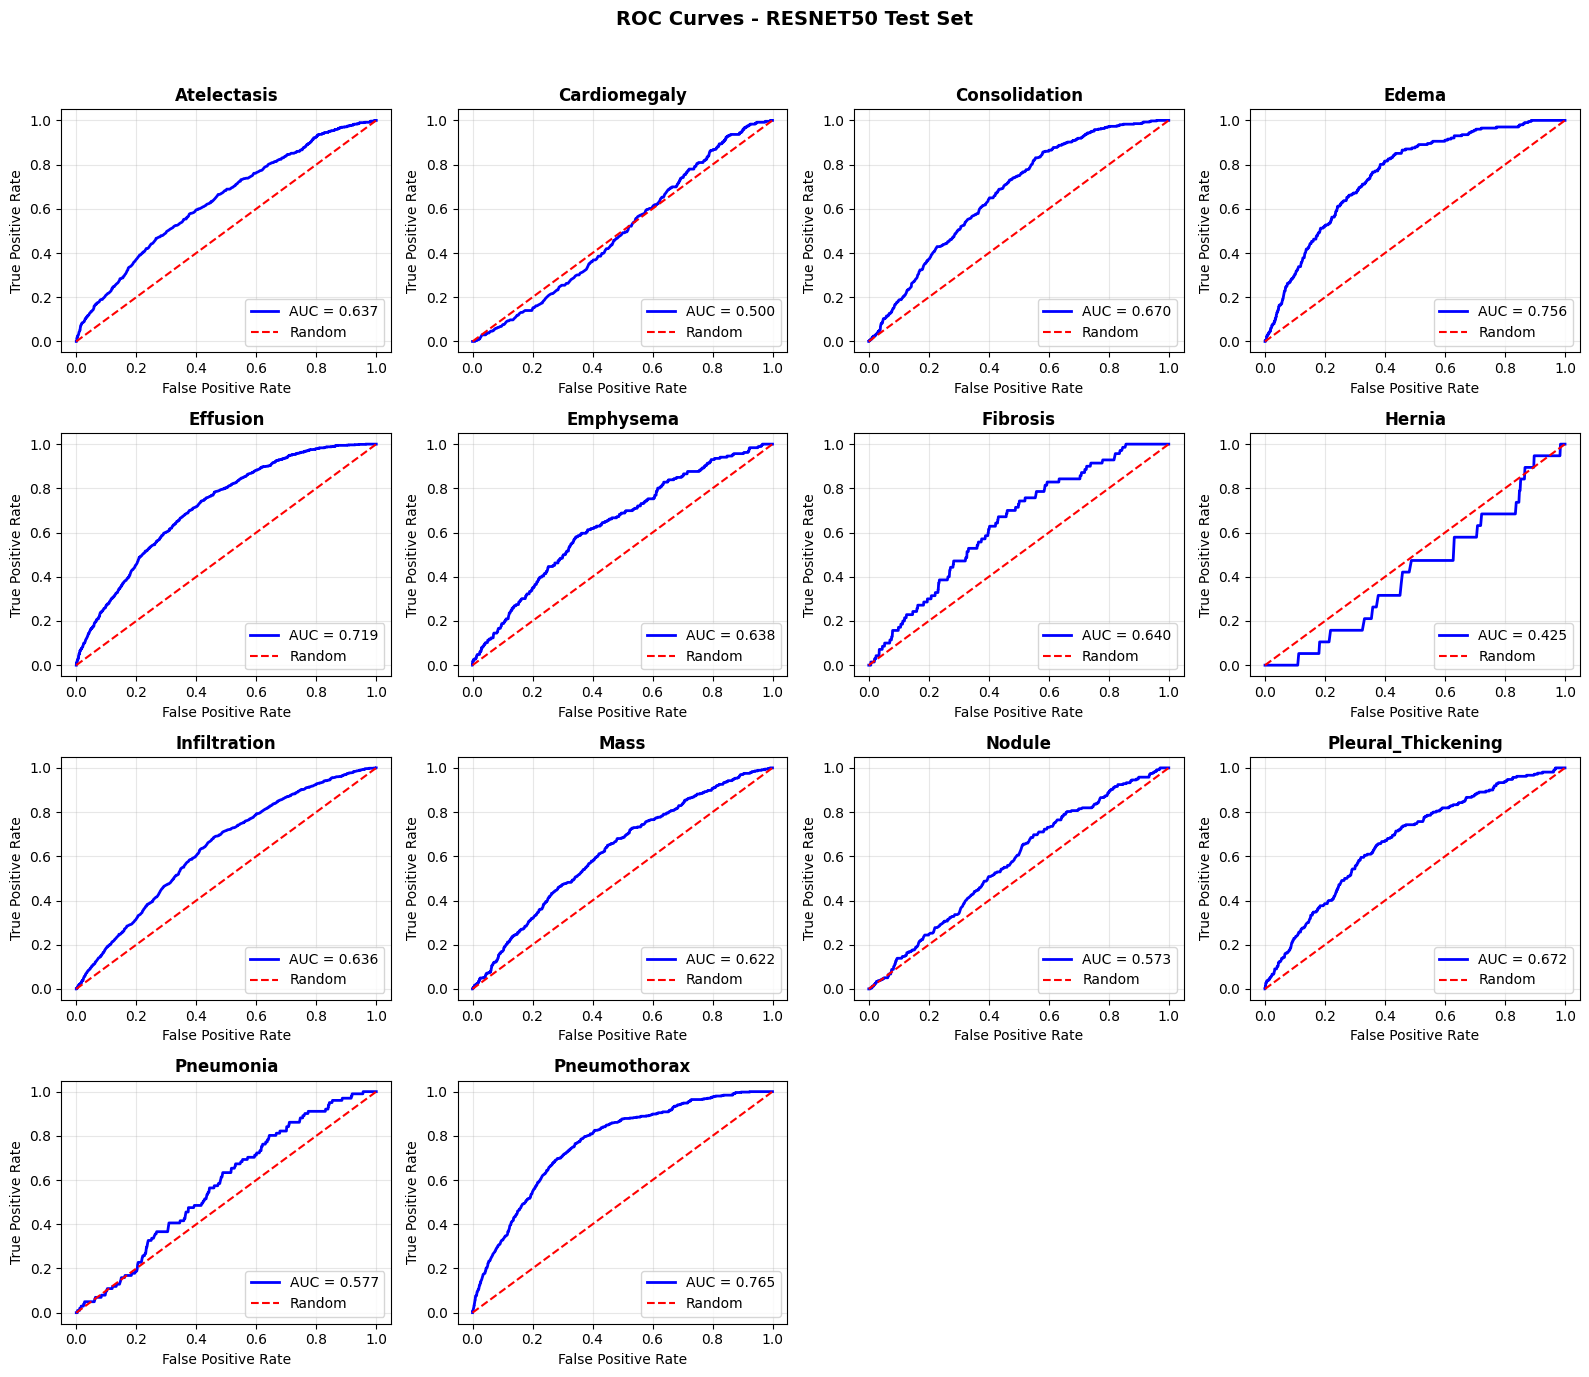

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(DISEASES):
    ax = axes[i]
    try:
        fpr, tpr, _ = roc_curve(test_true[:, i], test_preds[:, i])
        auc = roc_auc_score(test_true[:, i], test_preds[:, i])
        ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}', linewidth=2)
        ax.plot([0, 1], [0, 1], 'r--', label='Random')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(col, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
    except:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.set_title(col, fontweight='bold')

for j in range(len(DISEASES), 16):
    axes[j].axis('off')

plt.suptitle(f'ROC Curves - {MODEL_NAME.upper()} Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ENS_DIR / f'{MODEL_KEY}_roc_curves.png', dpi=150)
plt.show()

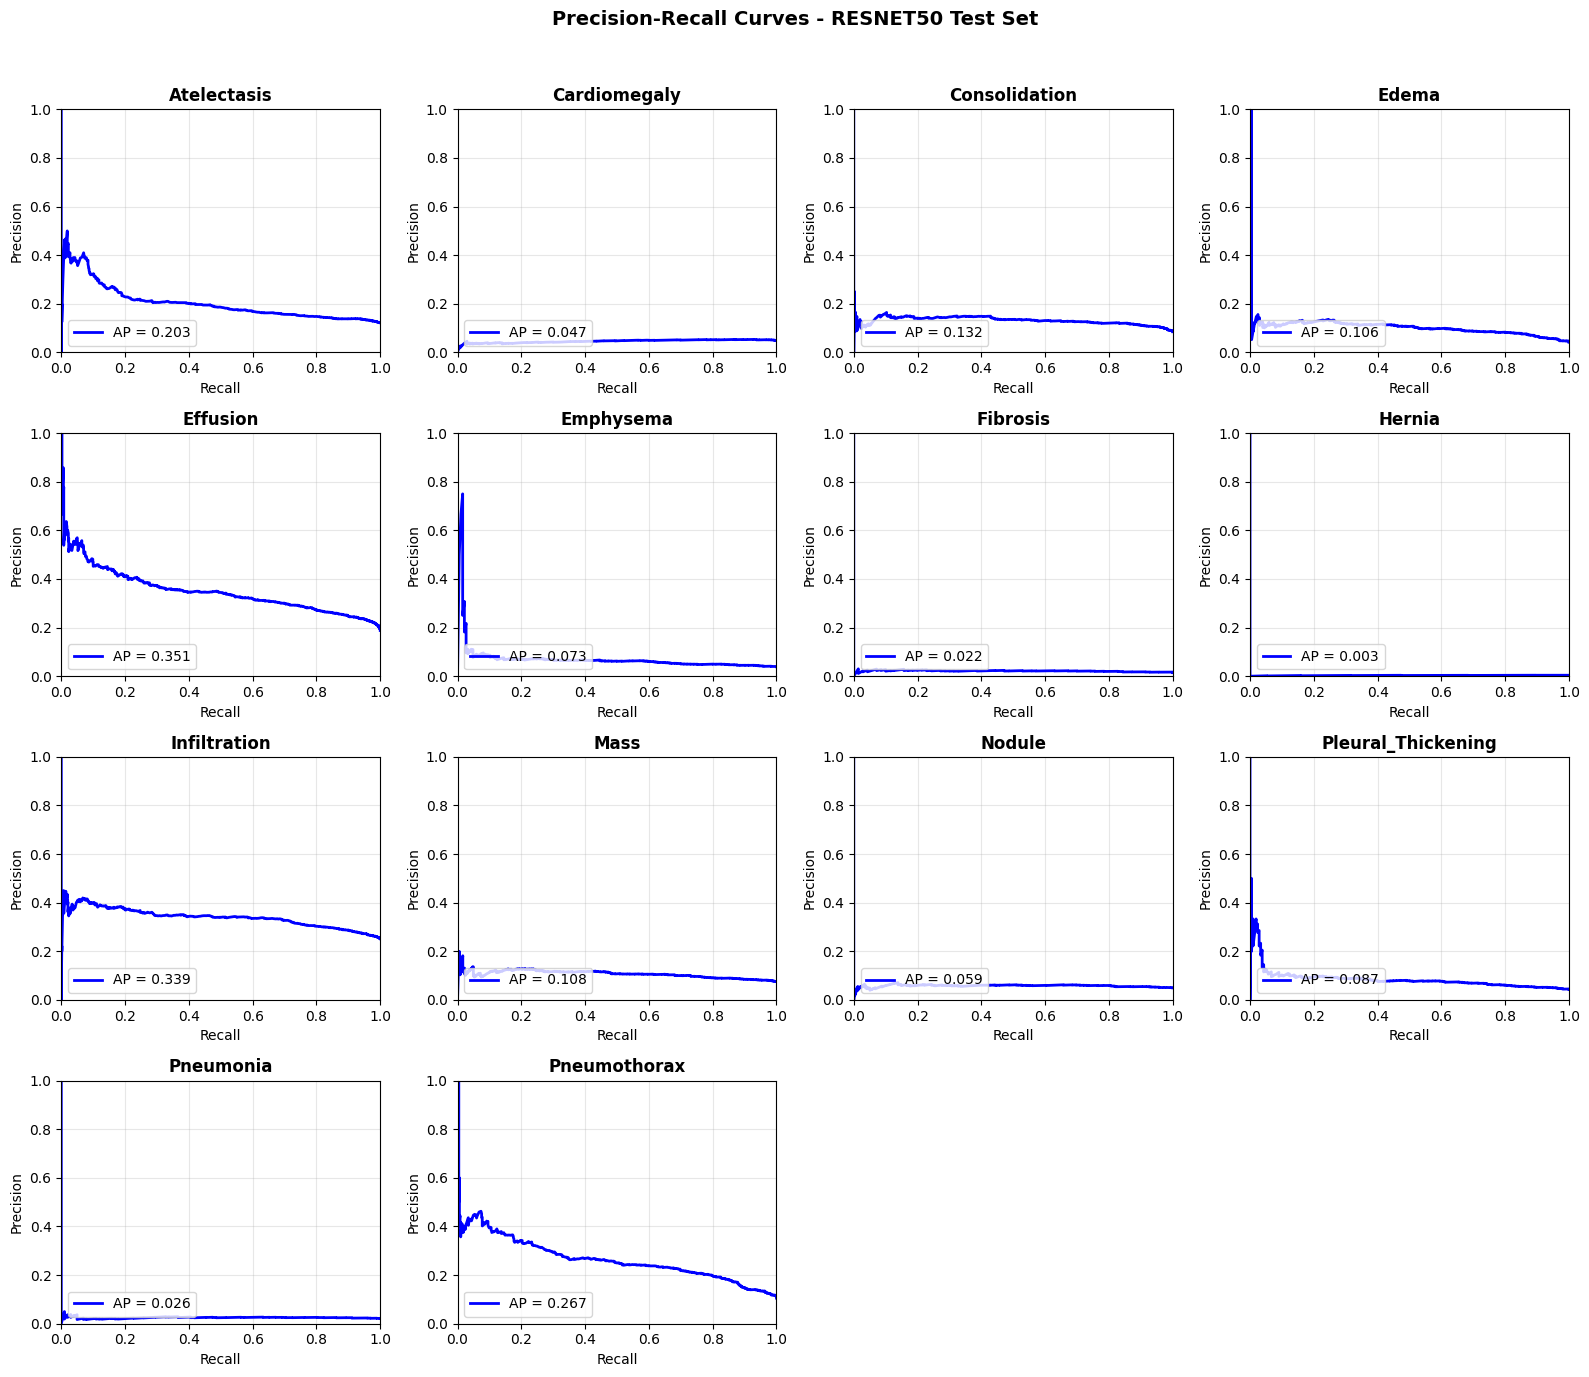

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(DISEASES):
    ax = axes[i]
    try:
        precision, recall, _ = precision_recall_curve(test_true[:, i], test_preds[:, i])
        ap = average_precision_score(test_true[:, i], test_preds[:, i])
        ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}', linewidth=2)
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(col, fontweight='bold')
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
    except:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.set_title(col, fontweight='bold')

for j in range(len(DISEASES), 16):
    axes[j].axis('off')

plt.suptitle(f'Precision-Recall Curves - {MODEL_NAME.upper()} Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ENS_DIR / f'{MODEL_KEY}_pr_curves.png', dpi=150)
plt.show()

## 13. Final Summary

In [21]:
print(f'\n{"="*60}')
print(f'FINAL SUMMARY - {MODEL_NAME.upper()}')
print(f'{"="*60}')
print(f'\nModel Configuration:')
print(f'  - Architecture: ResNet-50 (pretrained)')
print(f'  - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  - Preprocessing: Adaptive Lung Crop + CLAHE')
print(f'  - Loss: Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})')
print(f'  - Label smoothing: {LABEL_SMOOTHING}')

print(f'\nTraining Results:')
print(f'  - Best mode: {best_mode_name}')
print(f'  - Best fold: {best_fold_idx}')
print(f'  - OOF Macro AUC: {best_mode_auc*100:.2f}%')

print(f'\nTest Results (Optimal Thresholds):')
print(f'  - Mean AUC: {test_optimal["AUC-ROC"].mean():.2f}%')
print(f'  - Mean F1: {test_optimal["F1-Score"].mean():.2f}%')
print(f'  - Mean Precision: {test_optimal["Precision"].mean():.2f}%')
print(f'  - Mean Recall: {test_optimal["Recall"].mean():.2f}%')

print(f'\nTest Results (Fixed Threshold 0.5):')
print(f'  - Mean F1: {test_fixed["F1-Score"].mean():.2f}%')

print(f'\nOutput files saved to: {ENS_DIR}')
print(f'{"="*60}')


FINAL SUMMARY - RESNET50

Model Configuration:
  - Architecture: ResNet-50 (pretrained)
  - Image size: 256x256
  - Preprocessing: Adaptive Lung Crop + CLAHE
  - Loss: Focal Loss (alpha=1.0, gamma=2.0)
  - Label smoothing: 0.1

Training Results:
  - Best mode: early_stop
  - Best fold: 3
  - OOF Macro AUC: 69.18%

Test Results (Optimal Thresholds):
  - Mean AUC: 63.07%
  - Mean F1: 13.64%
  - Mean Precision: 12.34%
  - Mean Recall: 21.70%

Test Results (Fixed Threshold 0.5):
  - Mean F1: 1.67%

Output files saved to: /kaggle/working/output/ensemble_inputs
